In [18]:
import pickle

# Open the pickle file in binary read mode
with open('gradient_comparison_exponax_nu0.0005.pkl', 'rb') as file:
    # Load the data from the pickle file
    data = pickle.load(file)

In [2]:
data.keys()

dict_keys([('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.01000'), ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.05000'), ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.10000'), ('norm_inf', 'index_0', 'numsteps_50', 'epsilon_0.1', 'alpha_0.02000'), ('norm_inf', 'index_0', 'numsteps_50', 'epsilon_0.1', 'alpha_0.10000'), ('norm_inf', 'index_0', 'numsteps_50', 'epsilon_0.1', 'alpha_0.20000'), ('norm_inf', 'index_0', 'numsteps_10', 'epsilon_0.1', 'alpha_0.10000'), ('norm_inf', 'index_0', 'numsteps_10', 'epsilon_0.1', 'alpha_0.50000'), ('norm_inf', 'index_0', 'numsteps_10', 'epsilon_0.1', 'alpha_1.00000')])

In [5]:
data[('norm_inf', 'index_0', 'numsteps_100', 'epsilon_1', 'alpha_0.01000')].keys()

dict_keys(['step_update', 'final_values'])

In [6]:
data[('norm_inf', 'index_0', 'numsteps_100', 'epsilon_1', 'alpha_0.01000')]['step_update']

{'step_0': {'grad_metrics': {'vec1_length': 1024,
   'vec2_length': 1024,
   'vec1_norm': 20802.404125741756,
   'vec2_norm': 10416.596520079247,
   'norm_ratio': 1.9970442443117202,
   'rmse': 325.1334064145291,
   'cosine_similarity': 0.9991143719864516,
   'angle_degrees': 2.4115449428686895},
  'loss_metrics': {'before': {'with_solver': {'combined_loss': 68847.45521846812},
    'with_solver_on_without': {'combined_loss': 68847.45521846812}},
   'after': {'with_solver': {'combined_loss': 74469.51669192733},
    'with_solver_on_without': {'combined_loss': 74464.22355688101}}},
  'timing_metrics': {'with_solver': {'with_solver_forward_time': 1.6638407707214355,
    'with_solver_G_time': 0.003829479217529297,
    'with_solver_g_time': 1.6596953868865967,
    'with_solver_norm_time': 0.00029921531677246094,
    'with_solver_backward_time': 2.111692428588867},
   'without_solver': {'without_solver_forward_time': 0.15926837921142578,
    'without_solver_G_time': 0.0029211044311523438,
   

In [3]:
import matplotlib.pyplot as plt

def plot_after_loss(data, key):
    norm_type, index, numsteps, epsilon, alpha = key
    # Prepare data for plotting
    steps = range(0, len(data))  # Steps 1 to 100
    with_solver_loss = []
    without_solver_loss = []
    approximate_loss= []
    
    for step in steps:
        step_key = f'step_{step}'  # Since original data has steps 0-99
        with_solver_loss.append(data[step_key]['loss_metrics']['with_solver'])
        without_solver_loss.append(data[step_key]['loss_metrics']['without_solver'])
        approximate_loss.append(data[step_key]['loss_metrics']['approximate'])
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    # Plot the original lines (for reference)
    plt.plot(steps, with_solver_loss, label='With PDE Solver Gradient', marker='o', markersize=3, linestyle='-', alpha=1)
    plt.plot(steps, without_solver_loss, label='PDE detached Gradient', marker='o', markersize=3, linestyle='-', alpha=1)
    plt.plot(steps, approximate_loss, label='PDE approximated Gradient', marker='o', markersize=3, linestyle='-', alpha=1)
    
    # Plot the flipped lines (main plot)
    max_loss = max(max(with_solver_loss), max(without_solver_loss), max(approximate_loss))
    min_loss = min(min(with_solver_loss), min(without_solver_loss), min(approximate_loss))
    
    plt.gca().invert_yaxis()

    # Format plot
    plt.xlabel('Step Number')
    plt.ylabel('Loss ($||FNO(input)-PDE(input)||^2$) (flipped)')
    plt.title(
        f"With vs without solver gradient perturbation loss increase (vertically flipped)"
        "\n"
        f"Norm: {norm_type.split('_')[-1]} | Sample input index: {index.split('_')[-1]} | "
        f"Steps: {numsteps.split('_')[-1]} | ϵ: {epsilon.split('_')[-1]} | α: {alpha.split('_')[-1]}",
        y=1.05
    )
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    
    plt.tight_layout()
    plt.show()


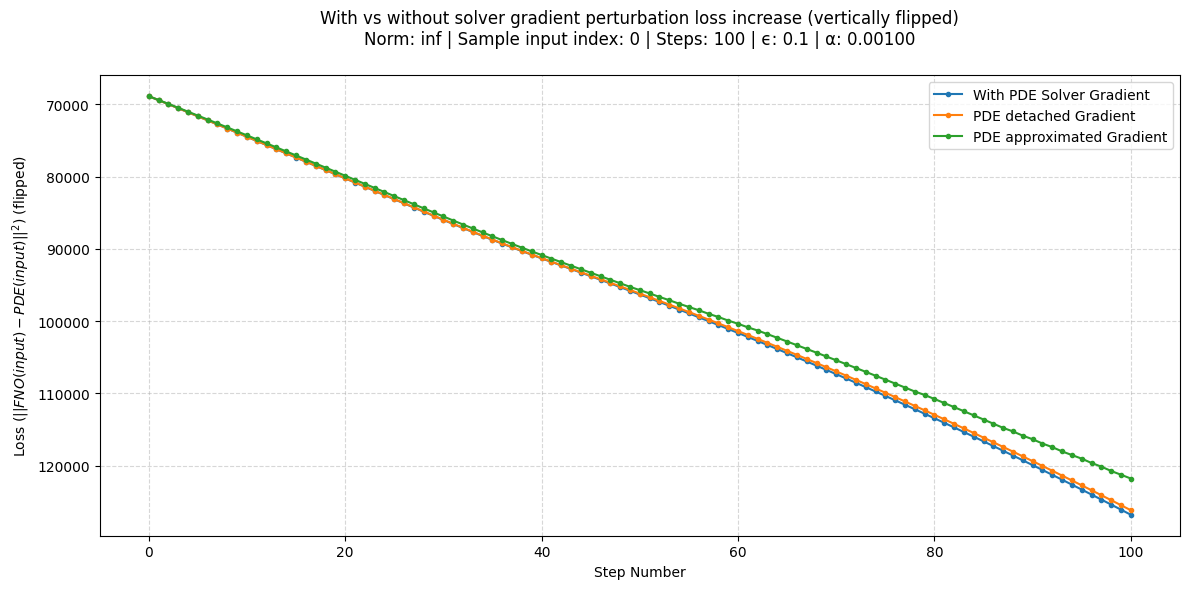

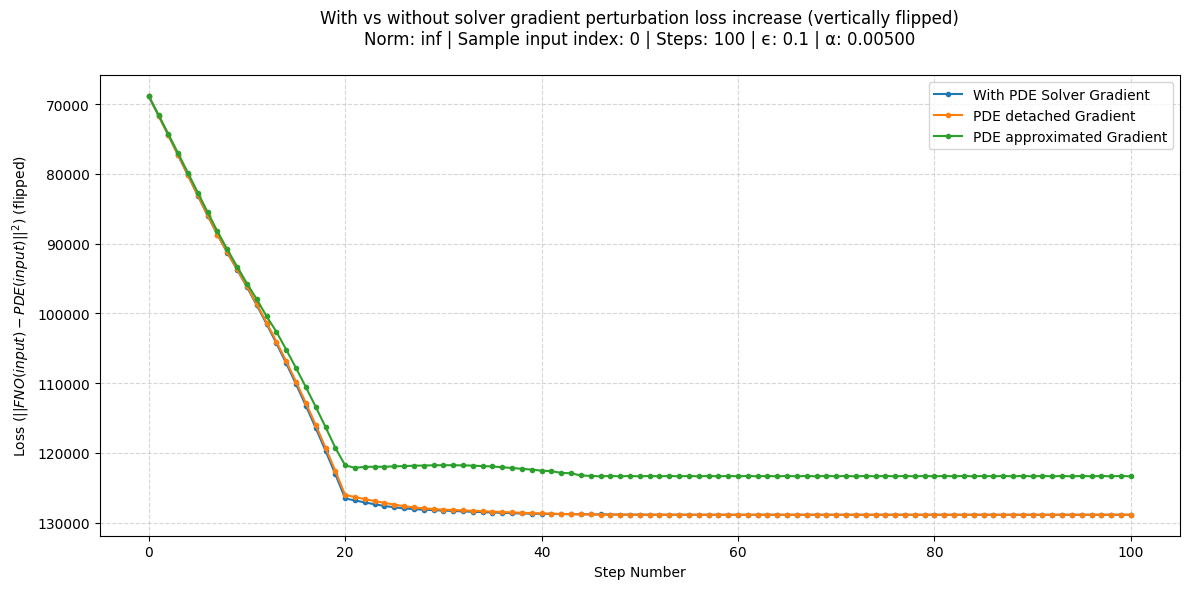

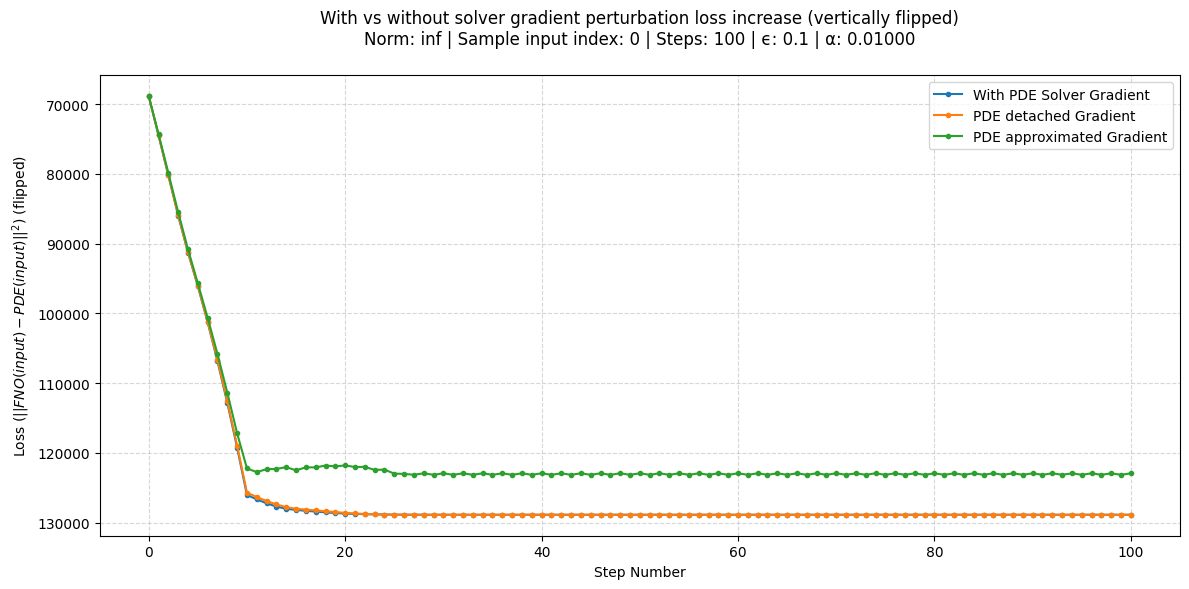

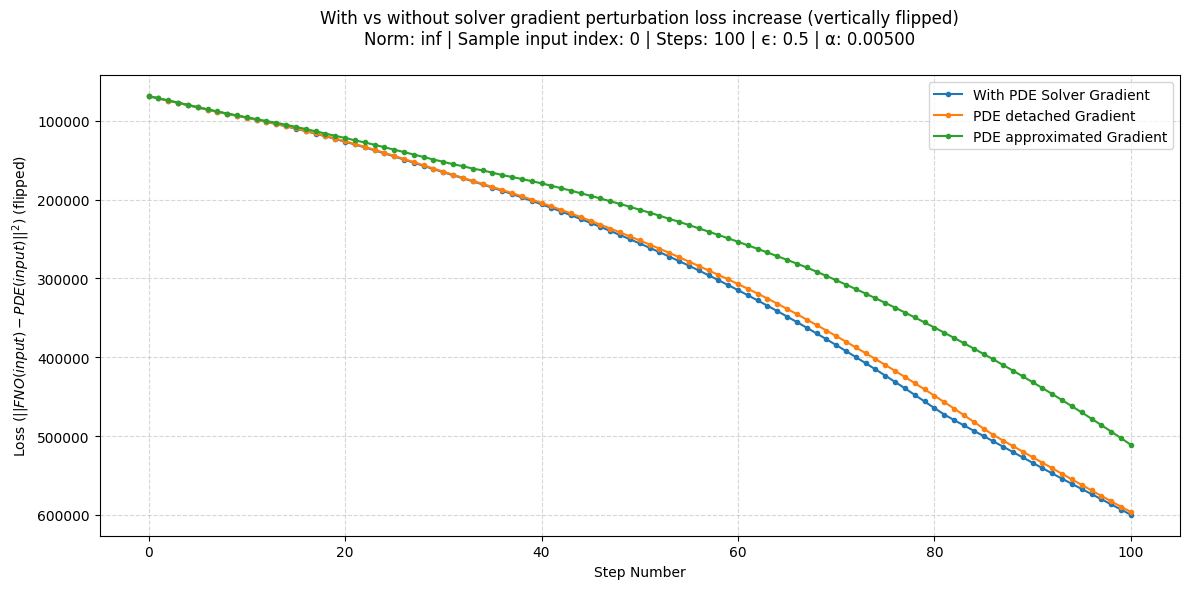

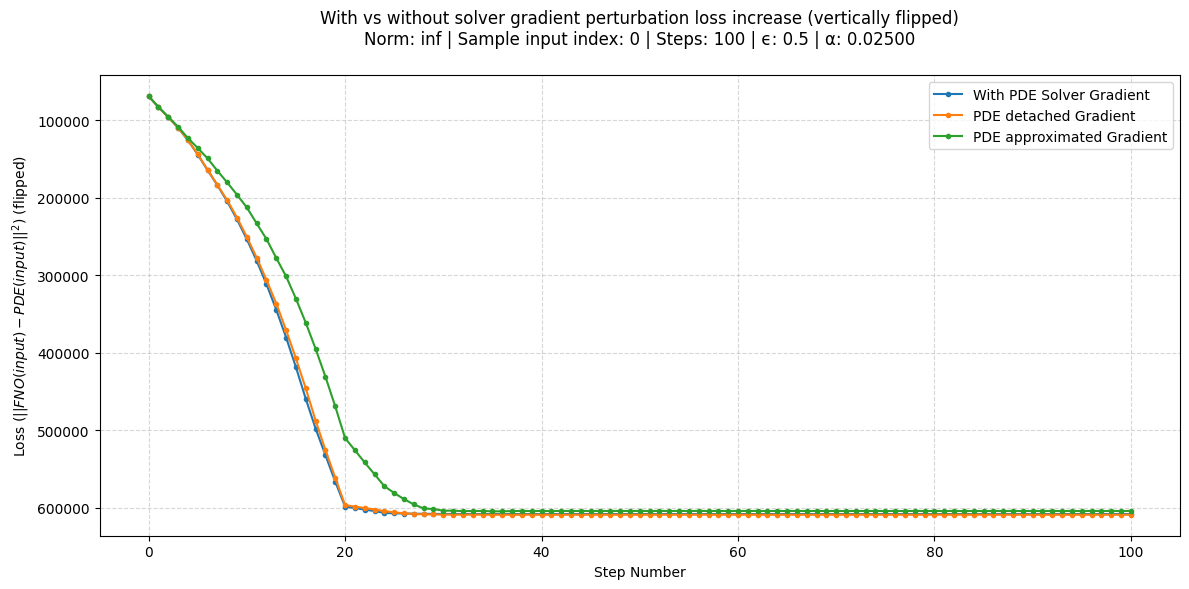

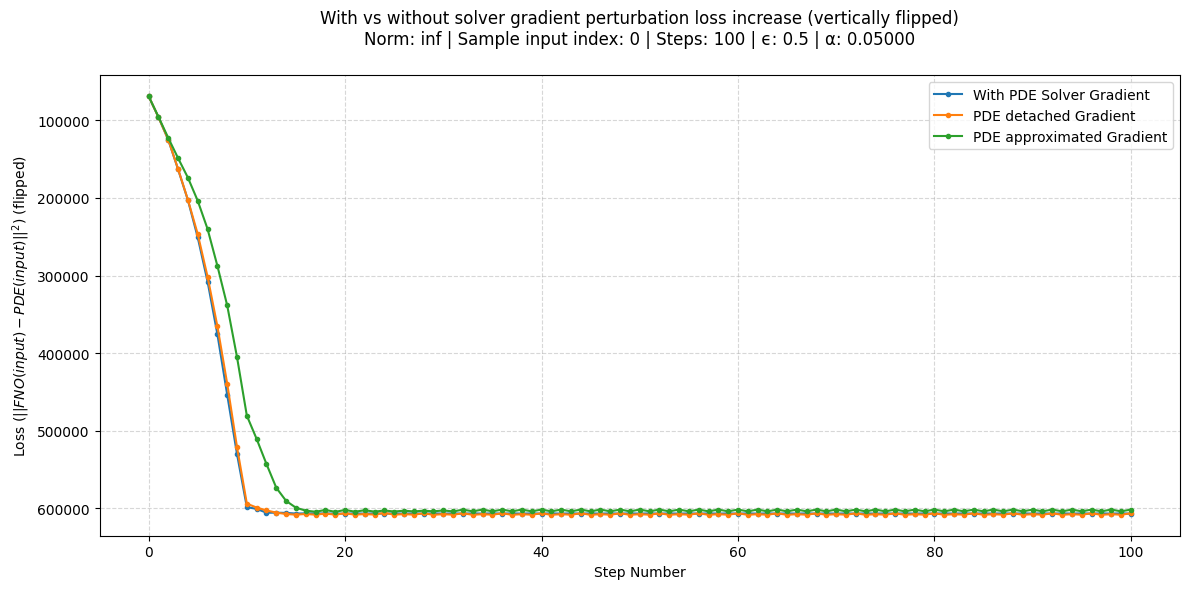

In [12]:
key = ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.00100')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.00500')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.01000')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.5', 'alpha_0.00500')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.5', 'alpha_0.02500')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.5', 'alpha_0.05000')
plot_after_loss(data[key]['step_update'], key)

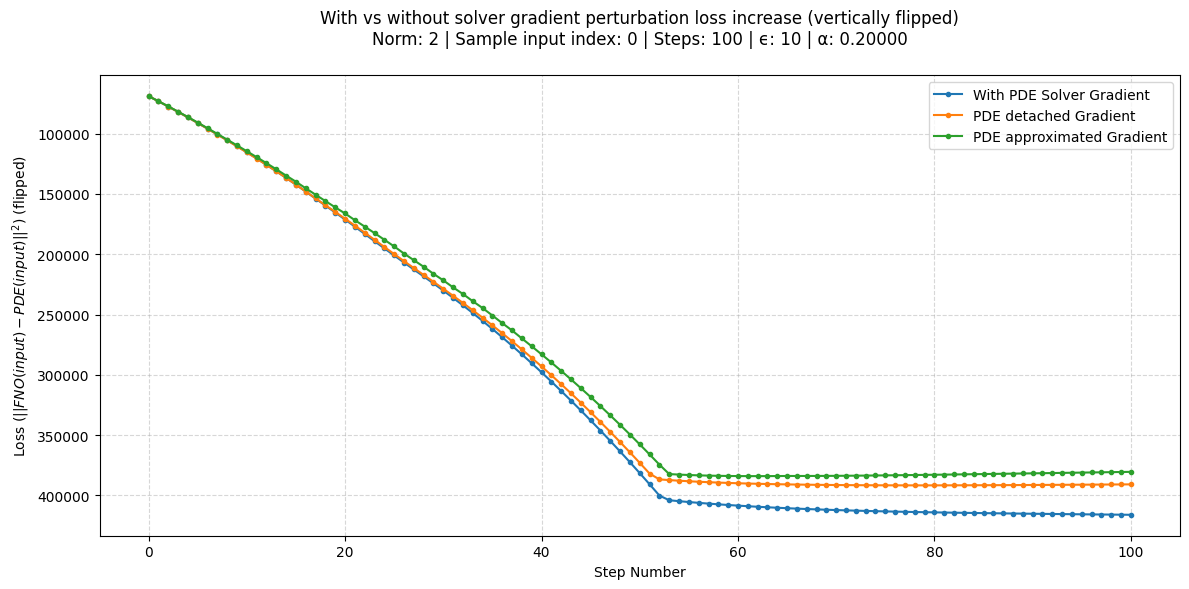

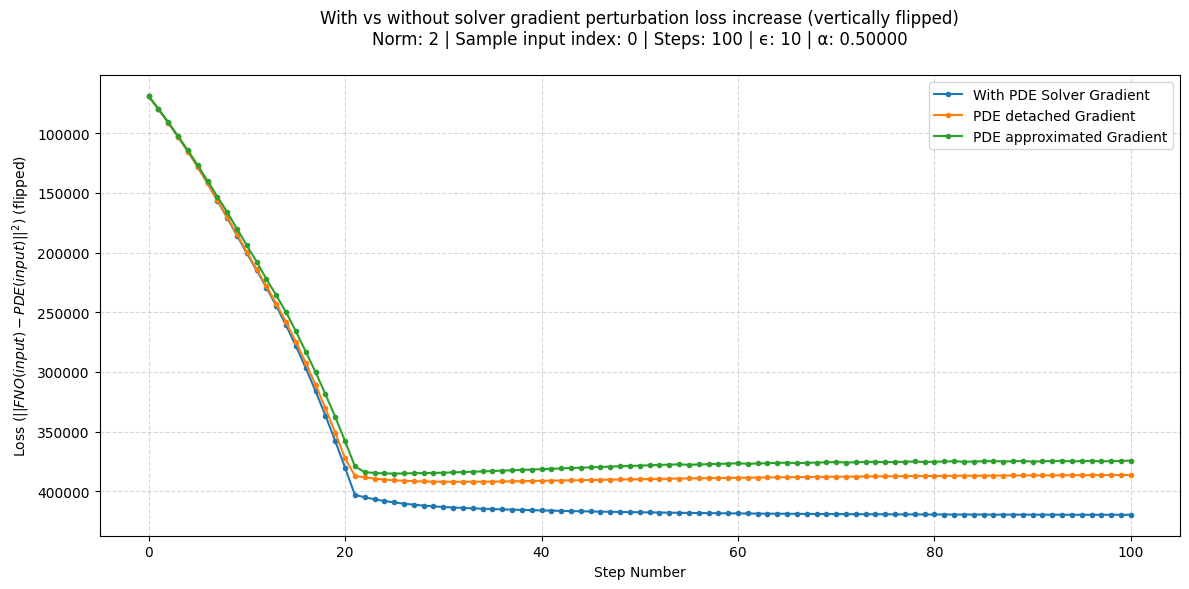

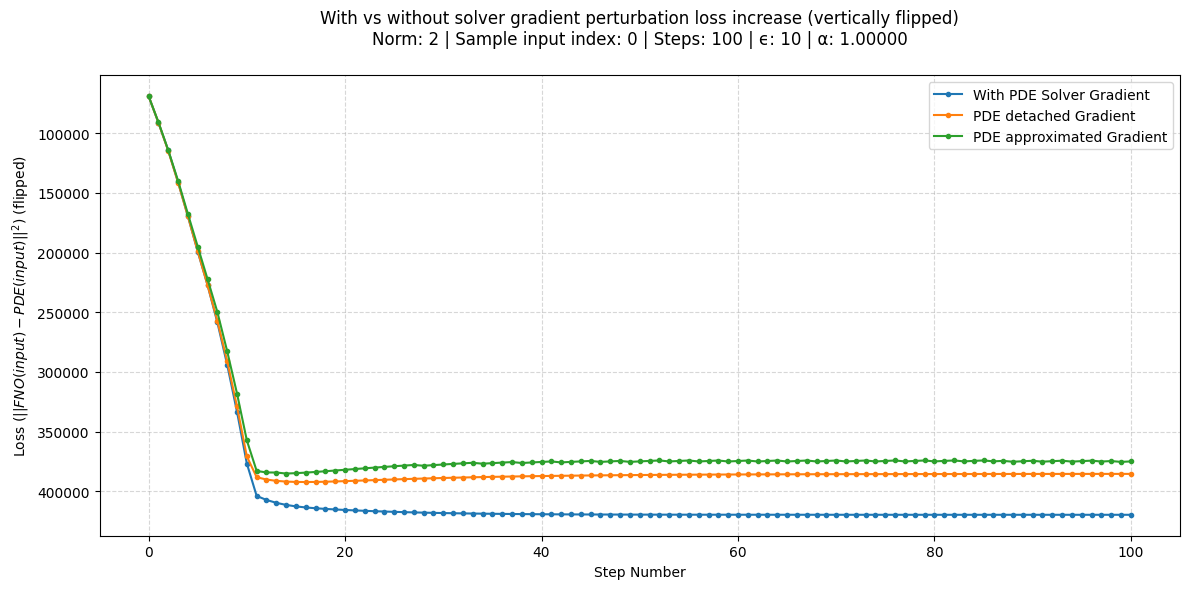

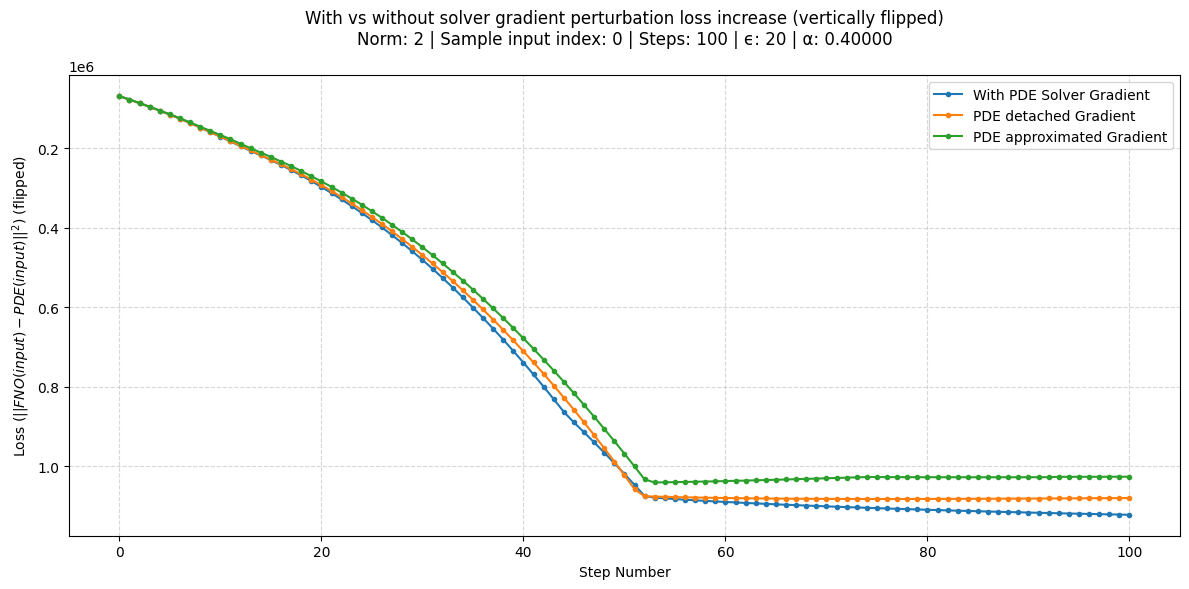

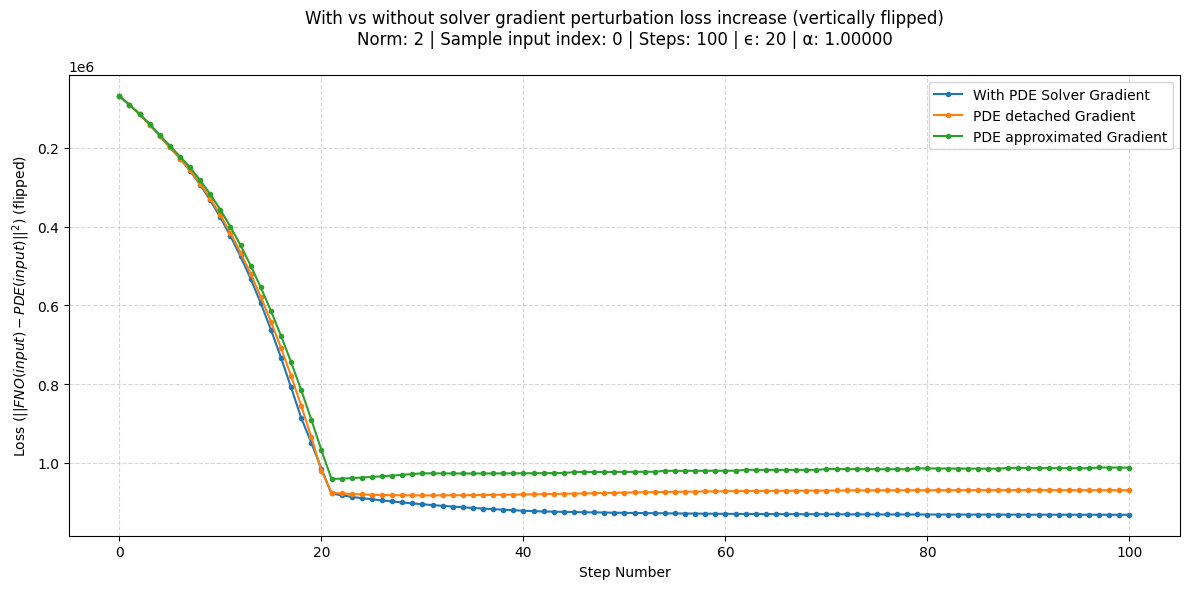

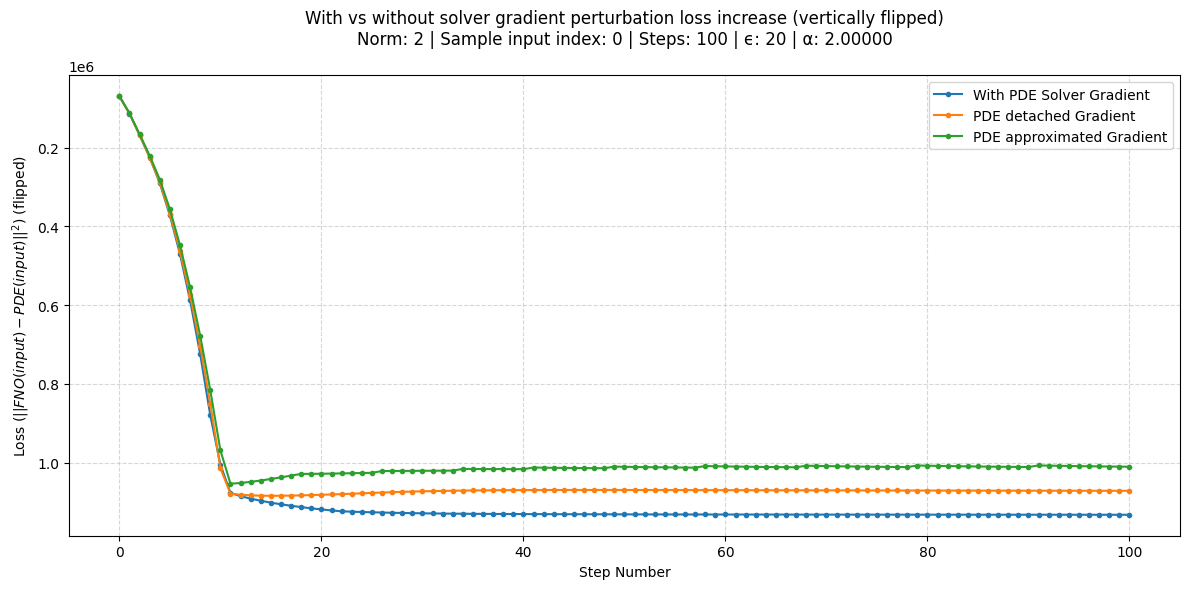

In [19]:
key = ('norm_2', 'index_0', 'numsteps_100', 'epsilon_10', 'alpha_0.20000')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_2', 'index_0', 'numsteps_100', 'epsilon_10', 'alpha_0.50000')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_2', 'index_0', 'numsteps_100', 'epsilon_10', 'alpha_1.00000')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_2', 'index_0', 'numsteps_100', 'epsilon_20', 'alpha_0.40000')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_2', 'index_0', 'numsteps_100', 'epsilon_20', 'alpha_1.00000')
plot_after_loss(data[key]['step_update'], key)
key = ('norm_2', 'index_0', 'numsteps_100', 'epsilon_20', 'alpha_2.00000')
plot_after_loss(data[key]['step_update'], key)

In [15]:
data.keys()

dict_keys([('norm_2', 'index_0', 'numsteps_100', 'epsilon_10', 'alpha_0.01000'), ('norm_2', 'index_0', 'numsteps_100', 'epsilon_10', 'alpha_0.05000'), ('norm_2', 'index_0', 'numsteps_100', 'epsilon_10', 'alpha_0.10000'), ('norm_2', 'index_0', 'numsteps_100', 'epsilon_20', 'alpha_0.02000'), ('norm_2', 'index_0', 'numsteps_100', 'epsilon_20', 'alpha_0.10000'), ('norm_2', 'index_0', 'numsteps_100', 'epsilon_20', 'alpha_0.20000'), ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.00100'), ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.00500'), ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.01000'), ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.5', 'alpha_0.00500'), ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.5', 'alpha_0.02500'), ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.5', 'alpha_0.05000')])